# 가우시안 노이즈
- noiy_pixel = original_pixel + N(u=0, e=scale)

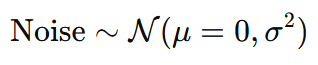

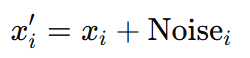

- 평균=0: 픽셀을 전체적으로 밝히거나 어둡게 하지 않음
- 표준편차(sclae): 값이 클수록 노이즈가 강해진다 (ex. 0.8->노이즈의 양이 많고, 숫자 일부가 흐릿하게 보임. 안 좋은 것)

##### 사용 목적
- 데이터 증강(Data Augmentation): 과적합 방지, 일반화 성능 향상, 강건성 향상, 데이터 증강

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor

In [2]:
# 가우스 잡음 추가 함수
def gaussian_noise(x, scale=0.8):
    gaussian_data_x= x+  np.random.normal(
        loc=0, scale=scale, size=x.shape
    )
    gaussian_data_x = np.clip(gaussian_data_x, 0, 1) #이미지픽셀의 값을 0~1 사이로 정규화
    gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)
    return gaussian_data_x

In [4]:
train_data = MNIST(root='./', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='./', train=False, download=True, transform=ToTensor())

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25036\2454124957.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gaussian_data_x= x+  np.random.normal(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25036\2454124957.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)


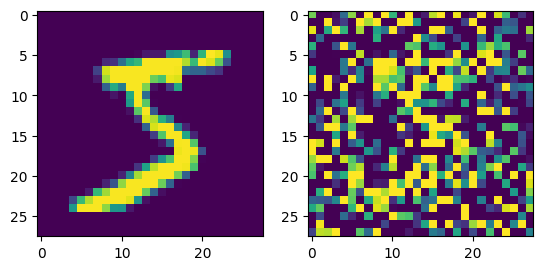

In [43]:
img, label = next(iter(train_data))
gaussian = gaussian_noise(img)

img = img.permute(1,2,0)
gaussian = gaussian.permute(1,2,0)

plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(gaussian)
plt.show()


In [33]:
# 학습용 데이터셋
from torch.utils.data.dataset import Dataset

class Denoise(Dataset):
    def __init__(self):
        self.mnist = MNIST(root='./', train=True, download=True, transform=ToTensor())
        self.data = []
        # 잡음 입히기
        for data, label in self.mnist:
            noisy = gaussian_noise(data)
            self.data.append(noisy)  #(1,1,28,28)                       

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        data = self.data[index]
        label = self.mnist.data[index] / 255 #원본이미지 0~1사이로 정규화
        return data, label

In [20]:
# 합성곱 기본 블럭
import torch.nn as nn

# Conv -> ReLU -> Conv -> ReLU
class BasicBlock(nn.Module):
    def __init__(self, in_channel, out_channel, hidden_channel):
        super(BasicBlock, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channel, hidden_channel, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channel, out_channel, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

In [21]:
sample_data = torch.randn(1,1,28,28)
sample_model = BasicBlock(1,20,10)
sample_model(sample_data).size()

torch.Size([1, 20, 28, 28])

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder,self).__init__()
        self.conv1 = BasicBlock(1,16,16)
        self.conv2 = BasicBlock(16,18,8)
        self.pool = nn.AvgPool2d(2)

    def forward(self, x):
        x = self.pool(self.conv1(x))  #(1,16,14,41)
        out = self.pool(self.conv2(x))  #(1,18,7,7)
        return out

In [ ]:
sample_data = torch.randn(1,1,28,28)
temp_encoder = Encoder()
result_encoder = temp_encoder(sample_data)

tensor([[[[1.0109e-01, 8.7178e-02, 9.0455e-02, 8.2405e-02, 8.5562e-02,
           8.5056e-02, 8.2445e-02],
          [1.0352e-01, 8.8454e-02, 9.7253e-02, 9.4241e-02, 8.8471e-02,
           8.8312e-02, 9.4356e-02],
          [1.0795e-01, 8.7314e-02, 9.3540e-02, 9.9435e-02, 9.5668e-02,
           8.5480e-02, 9.4490e-02],
          [1.0705e-01, 9.5365e-02, 9.1472e-02, 1.0096e-01, 8.1992e-02,
           9.5504e-02, 9.6227e-02],
          [1.0616e-01, 9.6813e-02, 8.3662e-02, 8.7468e-02, 9.3365e-02,
           1.0920e-01, 8.8790e-02],
          [1.0517e-01, 9.4119e-02, 8.9891e-02, 1.1127e-01, 8.9403e-02,
           9.6225e-02, 8.3161e-02],
          [1.1365e-01, 1.0487e-01, 9.4644e-02, 9.8676e-02, 1.0419e-01,
           1.0149e-01, 1.0288e-01]],

         [[4.6882e-02, 3.6625e-02, 4.2973e-02, 4.4285e-02, 4.0687e-02,
           4.6868e-02, 3.4598e-02],
          [3.4962e-02, 3.7505e-02, 2.8164e-02, 4.0053e-02, 3.8444e-02,
           3.0018e-02, 3.3229e-02],
          [3.5894e-02, 3.5417e-02, 

In [37]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder,self).__init__()
        self.conv1 = BasicBlock(18,8,8)
        self.conv2 = BasicBlock(8,16,16)
        # 출력층
        self.conv3 = nn.Conv2d(16,1,kernel_size=3,padding=1)

        # 업셈플링 층
        self.upsampling1 = nn.ConvTranspose2d(8,8,kernel_size=2, stride=2)
        self.upsampling2 = nn.ConvTranspose2d(16,16,kernel_size=2, stride=2)
    def forward(self,x):
        x = self.upsampling1(self.conv1(x))
        x = self.upsampling2(self.conv2(x))
        out = self.conv3(x)
        return out

In [40]:
# CAE 오토인코더
# 인코더와 디코더를 연결 : 인코더의 출력을 디코더의 입력으로 제공
class CAE(nn.Module):
    def __init__(self):
        super(CAE,self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

In [41]:
from tqdm import tqdm
from torch.utils.data.dataloader import DataLoader
from torch.optim.adam import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataset = Denoise()
train_loader = DataLoader(train_dataset, batch_size=32)

model = CAE().to(device)
criterion = nn.MSELoss()
optim = Adam(model.parameters(), lr=1e-3)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25036\2454124957.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gaussian_data_x= x+  np.random.normal(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25036\2454124957.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)


In [42]:
epochs = 20

for epoch in range(epochs):
    loop = tqdm(train_loader)
    for data, label in loop:
        data,label = data.to(device), label.to(device)
        optim.zero_grad()
        pred = model(data)
        loss = criterion(pred, label)
        loss.backward()
        optim.step()

        loop.set_postfix({'loss':f'{loss.item():.4f}'})
        
torch.save(model.state_dict(), 'CAE.pth')
    

  0%|          | 0/1875 [00:00<?, ?it/s]

c:\python_src\.venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([32, 28, 28])) that is different to the input size (torch.Size([32, 1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
 41%|████      | 764/1875 [01:10<01:41, 10.91it/s, loss=0.0768]


KeyboardInterrupt: 